# 02. Описательная статистика и EDA

Этот ноутбук содержит:
1. Описательную статистику всех переменных (полный период + подпериоды)
2. Графики временных рядов
3. Корреляционный анализ
4. Тесты стационарности (ADF)
5. Проверку мультиколлинеарности (VIF)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Загружаем обработанный датасет
df = pd.read_csv('../data/processed/merged_weekly.csv', index_col='date', parse_dates=True)

# Подпериоды
p1 = df.loc['2017-01-01':'2019-12-31']
p2 = df.loc['2020-01-01':'2025-03-01']

print(f'Полный период: {df.index.min().date()} — {df.index.max().date()}, наблюдений: {len(df)}')
print(f'Подпериод 1 (2017–2019): {len(p1)} недель')
print(f'Подпериод 2 (2020–2025): {len(p2)} недель')

Полный период: 2017-01-29 — 2025-02-23, наблюдений: 422
Подпериод 1 (2017–2019): 153 недель
Подпериод 2 (2020–2025): 269 недель


## 1. Описательная статистика

In [12]:
# Метки переменных для таблиц
var_labels = {
    'r_btc': 'BTC доходность',
    'r_btc_lag': 'BTC доходность (лаг)',
    'log_volume_btc': 'Log объём BTC',
    'google_trends': 'Google Trends',
    'r_sp500': 'S&P 500 доходность',
    'vix': 'VIX',
    'r_dxy': 'DXY доходность',
    'r_gold': 'Золото доходность',
    'd_yield_10y': 'Δ доходность 10Y Treasury (п.п.)',
    'epu': 'Global EPU',
}

def describe_extended(data, label=''):
    """Описательная статистика с асимметрией и эксцессом."""
    result = []
    for col in data.columns:
        s = data[col].dropna()
        result.append({
            'Переменная': var_labels.get(col, col),
            'N': len(s),
            'Среднее': s.mean(),
            'Медиана': s.median(),
            'Ст. откл.': s.std(),
            'Мин': s.min(),
            'Макс': s.max(),
            'Асимметрия': s.skew(),
            'Эксцесс': s.kurt(),
        })
    out = pd.DataFrame(result).set_index('Переменная')
    return out.round(4)

print('=== ПОЛНЫЙ ПЕРИОД (2017–2025) ===')
stats_full = describe_extended(df)
display(stats_full)

=== ПОЛНЫЙ ПЕРИОД (2017–2025) ===


,N,Среднее,Медиана,Ст. откл.,Мин,Макс,Асимметрия,Эксцесс
Переменная,,,,,,,,
BTC доходность,422,0.0110,0.0079,0.1013,-0.4036,0.3648,-0.3822,1.8432
BTC доходность (лаг),422,0.0113,0.0082,0.1014,-0.4036,0.3648,-0.3863,1.8268
Log объём BTC,422,14.2320,13.8253,1.6890,12.2604,23.6334,2.7279,10.3740
Google Trends,422,40.8673,36.0000,20.9306,4.0000,100.0000,0.6523,0.0517
S&P 500 доходность,422,0.0023,0.0048,0.0246,-0.1623,0.1142,-0.9351,7.6416
VIX,422,18.7538,17.1060,7.5510,9.3400,74.6180,2.4451,11.4125
DXY доходность,422,0.0001,0.0008,0.0090,-0.0443,0.0404,-0.2392,3.0679
Золото доходность,422,0.0021,0.0028,0.0198,-0.0977,0.0904,-0.0620,2.5969
Δ доходность 10Y Treasury (п.п.),422,0.0046,0.0000,0.1162,-0.4000,0.3500,-0.1686,0.9196


In [13]:
print('=== ПОДПЕРИОД 1 (2017–2019) ===')
display(describe_extended(p1))

print('\n=== ПОДПЕРИОД 2 (2020–2025) ===')
display(describe_extended(p2))

=== ПОДПЕРИОД 1 (2017–2019) ===


,N,Среднее,Медиана,Ст. откл.,Мин,Макс,Асимметрия,Эксцесс
Переменная,,,,,,,,
BTC доходность,153,0.0136,0.0168,0.1245,-0.3608,0.3648,-0.2306,0.6894
BTC доходность (лаг),153,0.0145,0.0171,0.1247,-0.3608,0.3648,-0.2459,0.6702
Log объём BTC,153,14.5621,14.3270,1.1896,12.2997,17.9300,0.6086,0.0250
Google Trends,153,29.9346,25.0000,20.7414,4.0000,100.0000,1.3502,1.8503
S&P 500 доходность,153,0.0023,0.0049,0.0179,-0.0731,0.0473,-1.1256,3.2784
VIX,153,14.4547,13.2100,4.0743,9.3400,31.5100,1.4345,2.8637
DXY доходность,153,-0.0003,0.0002,0.0073,-0.0215,0.0139,-0.1760,-0.3535
Золото доходность,153,0.0015,0.0007,0.0143,-0.0332,0.0405,0.0357,-0.1405
Δ доходность 10Y Treasury (п.п.),153,-0.0039,-0.0100,0.0872,-0.2200,0.3500,0.5515,1.4281



=== ПОДПЕРИОД 2 (2020–2025) ===


,N,Среднее,Медиана,Ст. откл.,Мин,Макс,Асимметрия,Эксцесс
Переменная,,,,,,,,
BTC доходность,269,0.0095,0.0052,0.0855,-0.4036,0.2399,-0.6565,2.7229
BTC доходность (лаг),269,0.0095,0.0052,0.0856,-0.4036,0.2399,-0.6545,2.7186
Log объём BTC,269,14.0443,13.4139,1.8924,12.2604,23.6334,3.1493,11.2644
Google Trends,269,47.0855,43.0000,18.3617,21.0000,100.0000,0.7853,-0.0651
S&P 500 доходность,269,0.0023,0.0048,0.0277,-0.1623,0.1142,-0.8574,6.8264
VIX,269,21.1990,19.4820,7.9750,12.2000,74.6180,2.5367,11.2922
DXY доходность,269,0.0004,0.0012,0.0099,-0.0443,0.0404,-0.2779,3.2474
Золото доходность,269,0.0025,0.0037,0.0224,-0.0977,0.0904,-0.1012,2.1785
Δ доходность 10Y Treasury (п.п.),269,0.0094,0.0100,0.1298,-0.4000,0.3400,-0.3471,0.5335


## 2. Временные ряды

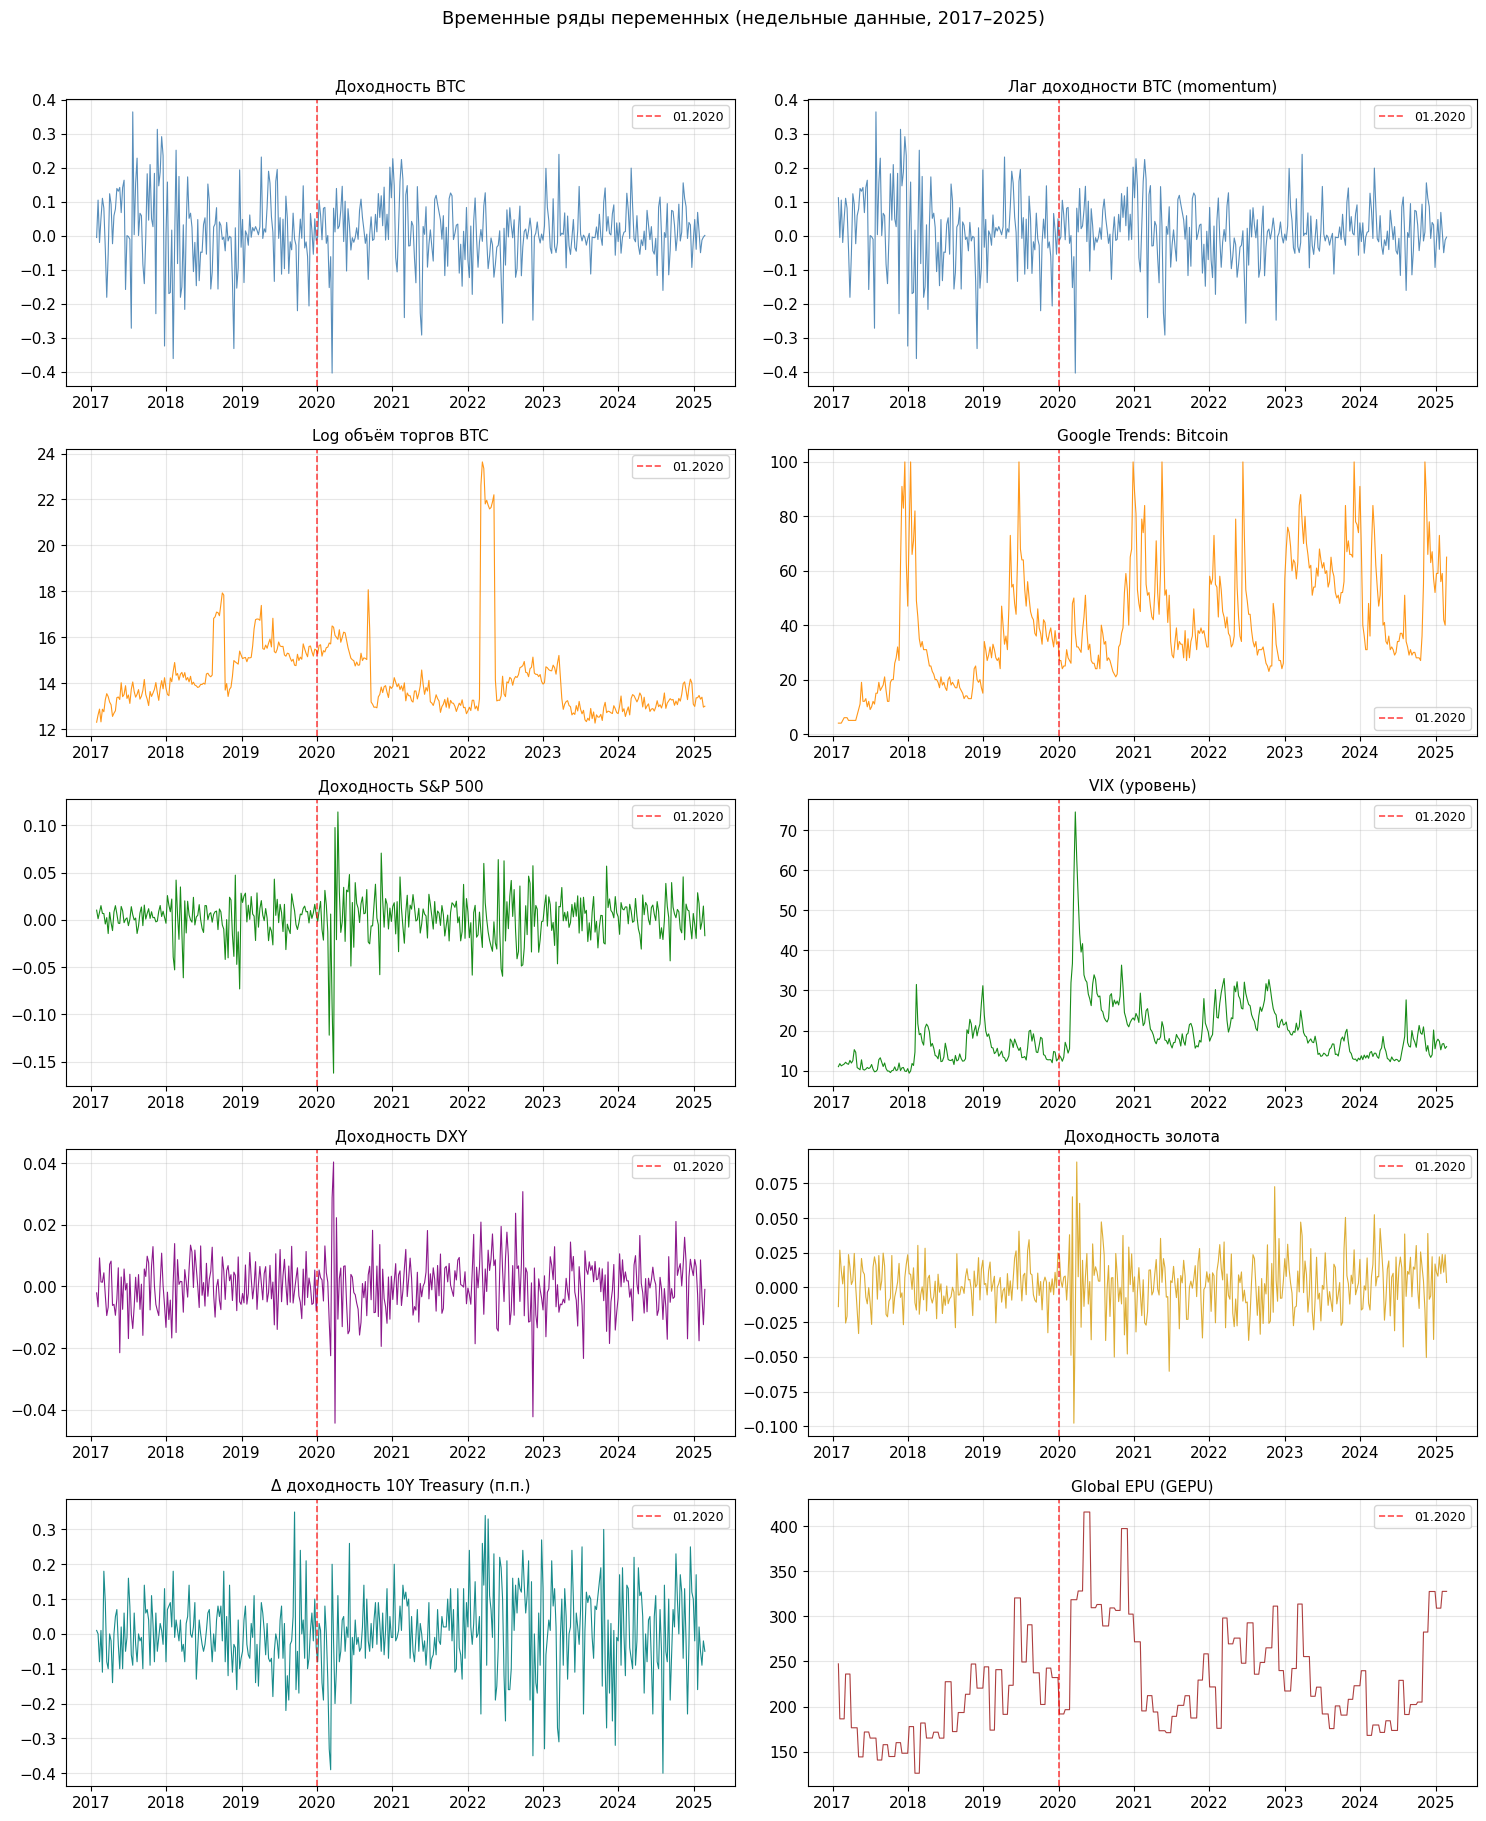

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
fig.suptitle('Временные ряды переменных (недельные данные, 2017–2025)', fontsize=13, y=1.01)

plot_vars = [
    ('r_btc', 'Доходность BTC', 'steelblue'),
    ('r_btc_lag', 'Лаг доходности BTC (momentum)', 'steelblue'),
    ('log_volume_btc', 'Log объём торгов BTC', 'darkorange'),
    ('google_trends', 'Google Trends: Bitcoin', 'darkorange'),
    ('r_sp500', 'Доходность S&P 500', 'green'),
    ('vix', 'VIX (уровень)', 'green'),
    ('r_dxy', 'Доходность DXY', 'purple'),
    ('r_gold', 'Доходность золота', 'goldenrod'),
    ('d_yield_10y', 'Δ доходность 10Y Treasury (п.п.)', 'teal'),
    ('epu', 'Global EPU (GEPU)', 'brown'),
]

axes_flat = axes.flatten()
for i, (var, title, color) in enumerate(plot_vars):
    ax = axes_flat[i]
    ax.plot(df.index, df[var], color=color, linewidth=0.8, alpha=0.9)
    ax.axvline(pd.Timestamp('2020-01-01'), color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='01.2020')
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/eda_timeseries.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Гистограммы и проверка нормальности

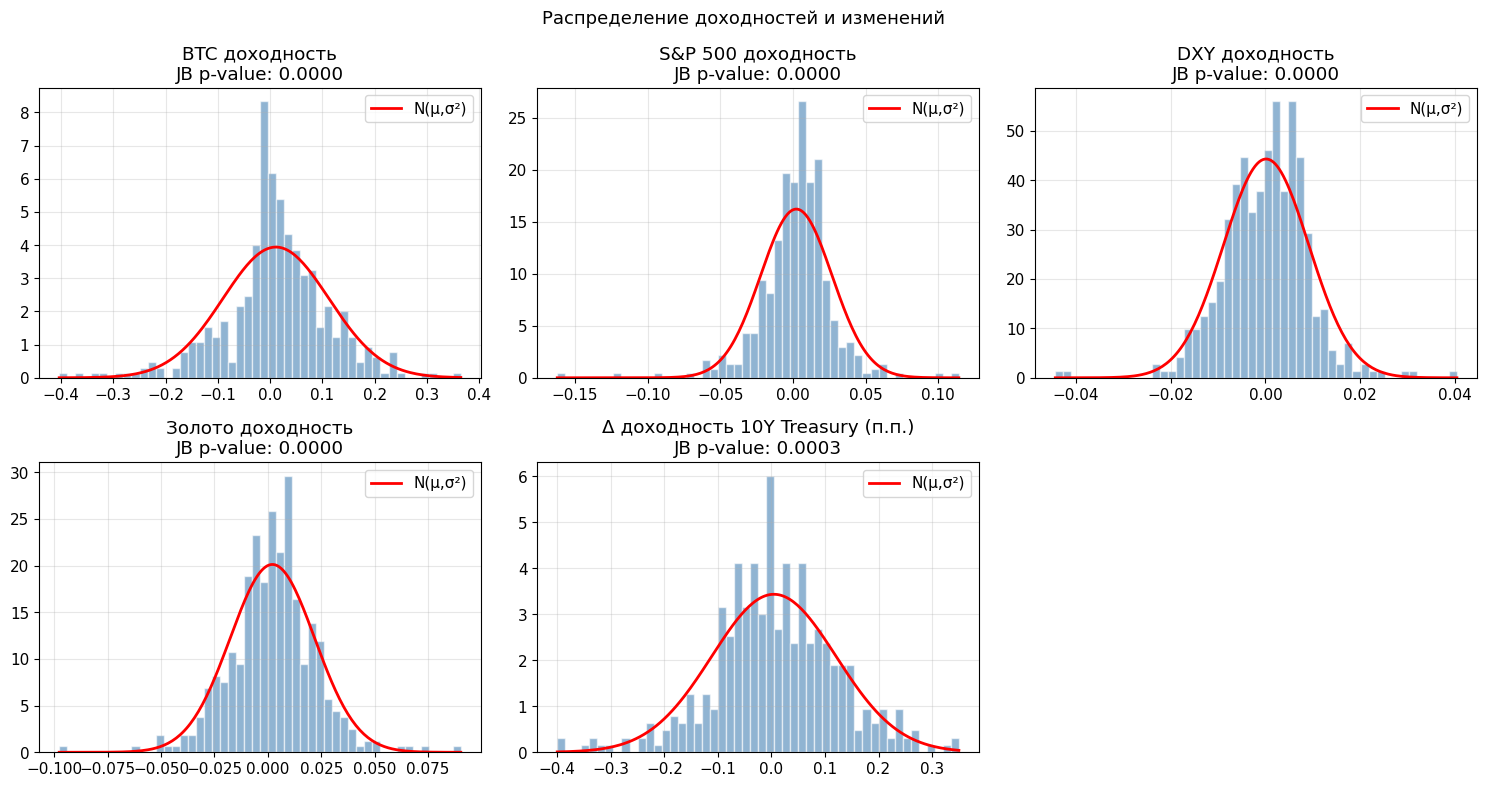

In [15]:
return_vars = ['r_btc', 'r_sp500', 'r_dxy', 'r_gold', 'd_yield_10y']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Распределение доходностей и изменений', fontsize=13)

axes_flat = axes.flatten()
for ax, var in zip(axes_flat, return_vars):
    s = df[var].dropna()
    ax.hist(s, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    # Наложим нормальное распределение
    x = np.linspace(s.min(), s.max(), 200)
    ax.plot(x, stats.norm.pdf(x, s.mean(), s.std()), 'r-', lw=2, label='N(μ,σ²)')
    # Тест Жарка-Бера
    jb_stat, jb_p = stats.jarque_bera(s)
    ax.set_title(f'{var_labels[var]}\nJB p-value: {jb_p:.4f}')
    ax.legend()
    ax.grid(alpha=0.3)

axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.savefig('../data/processed/eda_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Корреляционный анализ

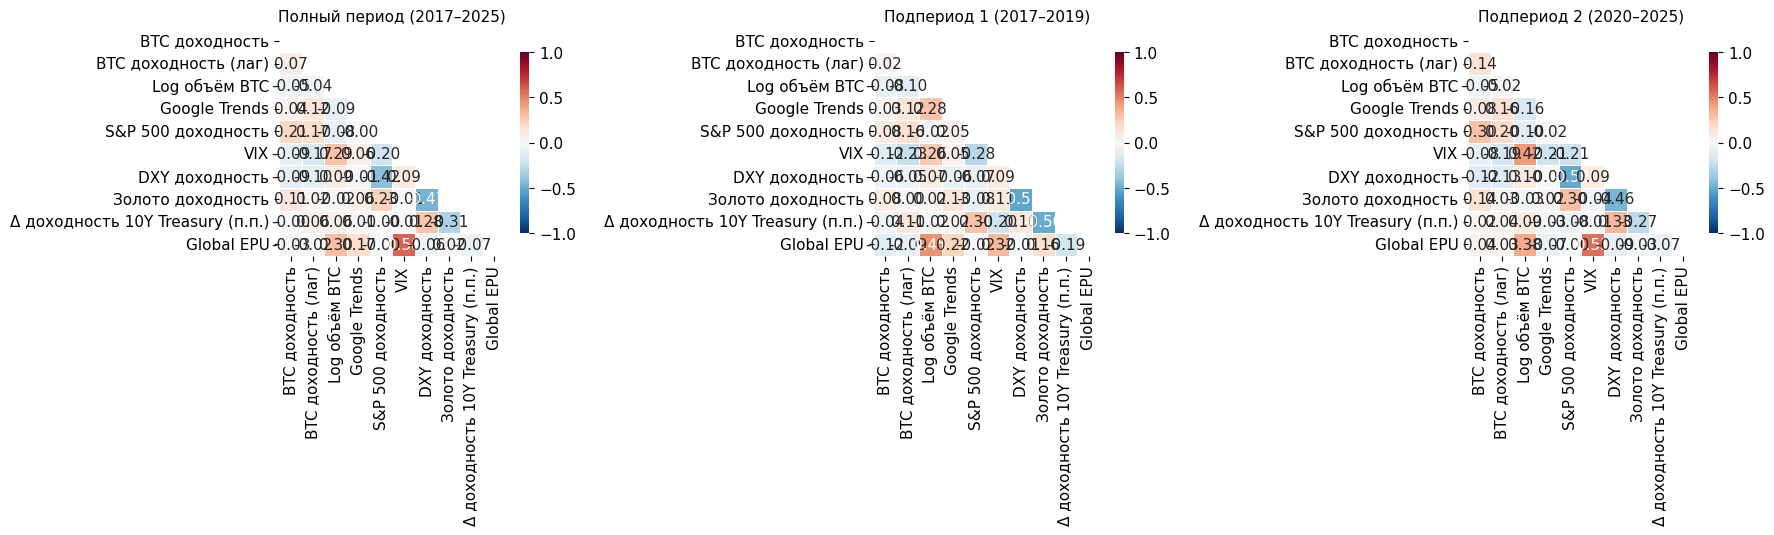

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Полный период (2017–2025)', 'Подпериод 1 (2017–2019)', 'Подпериод 2 (2020–2025)']
datasets = [df, p1, p2]

for ax, data, title in zip(axes, datasets, titles):
    corr = data.rename(columns=var_labels).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=ax, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('../data/processed/eda_correlations.png', dpi=100, bbox_inches='tight')
plt.show()

In [17]:
# Корреляции с r_btc отдельно для двух подпериодов
corr_comparison = pd.DataFrame({
    'Полный (2017–2025)': df.corr()['r_btc'],
    'Подпериод 1 (2017–2019)': p1.corr()['r_btc'],
    'Подпериод 2 (2020–2025)': p2.corr()['r_btc'],
}).drop('r_btc').rename(index=var_labels)

print('Корреляции переменных с доходностью BTC:')
display(corr_comparison.round(4))

Корреляции переменных с доходностью BTC:


,Полный (2017–2025),Подпериод 1 (2017–2019),Подпериод 2 (2020–2025)
BTC доходность (лаг),0.0745,0.0204,0.1385
Log объём BTC,-0.0543,-0.0790,-0.0540
Google Trends,0.0447,0.0329,0.0804
S&P 500 доходность,0.2051,0.0794,0.2961
VIX,-0.0851,-0.1244,-0.0826
DXY доходность,-0.0931,-0.0555,-0.1232
Золото доходность,0.1080,0.0757,0.1387
Δ доходность 10Y Treasury (п.п.),-0.0034,-0.0418,0.0193
Global EPU,-0.0273,-0.1197,0.0378


## 5. Тесты стационарности (ADF)

In [18]:
def adf_test(series, name):
    """Тест Дики-Фуллера на единичный корень."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Переменная': name,
        'ADF-статистика': round(result[0], 4),
        'p-value': round(result[1], 4),
        'Крит. знач. 1%': round(result[4]['1%'], 4),
        'Крит. знач. 5%': round(result[4]['5%'], 4),
        'Стационарна (5%)': 'Да' if result[1] < 0.05 else 'Нет',
    }

adf_results = [adf_test(df[col], var_labels.get(col, col)) for col in df.columns]
adf_df = pd.DataFrame(adf_results).set_index('Переменная')

print('Тест Дики-Фуллера (ADF) — H0: ряд нестационарен')
display(adf_df)

Тест Дики-Фуллера (ADF) — H0: ряд нестационарен


,ADF-статистика,p-value,Крит. знач. 1%,Крит. знач. 5%,Стационарна (5%)
Переменная,,,,,
BTC доходность,-18.9897,0.0000,-3.4460,-2.8684,Да
BTC доходность (лаг),-19.0225,0.0000,-3.4460,-2.8684,Да
Log объём BTC,-3.6375,0.0051,-3.4464,-2.8686,Да
Google Trends,-3.8762,0.0022,-3.4461,-2.8685,Да
S&P 500 доходность,-22.2457,0.0000,-3.4460,-2.8684,Да
VIX,-4.8547,0.0000,-3.4460,-2.8684,Да
DXY доходность,-22.7799,0.0000,-3.4460,-2.8684,Да
Золото доходность,-9.5422,0.0000,-3.4461,-2.8685,Да
Δ доходность 10Y Treasury (п.п.),-20.6818,0.0000,-3.4460,-2.8684,Да


## 6. Мультиколлинеарность (VIF)

In [19]:
from statsmodels.tools.tools import add_constant

regressors = ['r_btc_lag', 'log_volume_btc', 'google_trends', 'r_sp500', 'vix', 'r_dxy', 'r_gold', 'd_yield_10y', 'epu']
X = df[regressors].dropna()
X_const = add_constant(X)

vif_data = pd.DataFrame({
    'Переменная': [var_labels.get(c, c) for c in regressors],
    'VIF': [variance_inflation_factor(X_const.values, i+1) for i in range(len(regressors))]
})
vif_data['VIF'] = vif_data['VIF'].round(3)
vif_data['Оценка'] = vif_data['VIF'].apply(lambda x: 'Норма' if x < 5 else ('Умеренно' if x < 10 else 'Высокий'))

print('VIF (Variance Inflation Factor) для регрессоров полной модели')
print('Правило: VIF > 10 — серьёзная мультиколлинеарность')
display(vif_data)

VIF (Variance Inflation Factor) для регрессоров полной модели
Правило: VIF > 10 — серьёзная мультиколлинеарность


,Переменная,VIF,Оценка
0,BTC доходность (лаг),1.082,Норма
1,Log объём BTC,1.168,Норма
2,Google Trends,1.078,Норма
3,S&P 500 доходность,1.311,Норма
4,VIX,1.684,Норма
5,DXY доходность,1.570,Норма
6,Золото доходность,1.376,Норма
7,Δ доходность 10Y Treasury (п.п.),1.178,Норма
8,Global EPU,1.688,Норма


## 7. Скользящая корреляция BTC с S&P 500 и VIX

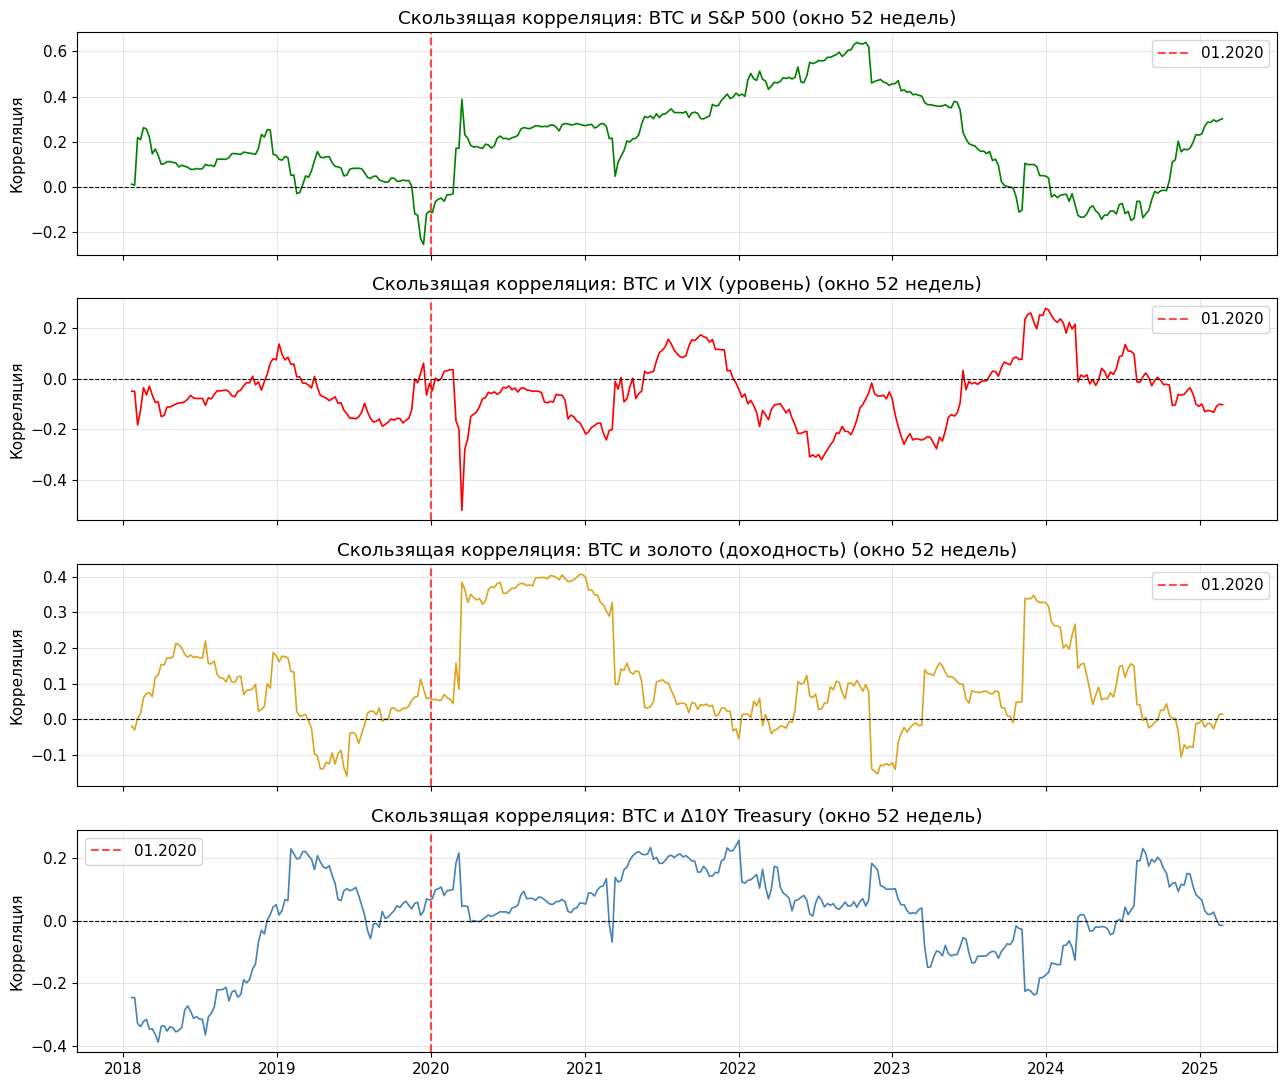

In [20]:
window = 52  # 52 недели = 1 год

roll_corr_sp500 = df['r_btc'].rolling(window).corr(df['r_sp500'])
roll_corr_vix = df['r_btc'].rolling(window).corr(df['vix'])
roll_corr_gold = df['r_btc'].rolling(window).corr(df['r_gold'])
roll_corr_yield = df['r_btc'].rolling(window).corr(df['d_yield_10y'])

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
series_axes = [
    (roll_corr_sp500, 'green', f'BTC и S&P 500'),
    (roll_corr_vix, 'red', f'BTC и VIX (уровень)'),
    (roll_corr_gold, 'goldenrod', f'BTC и золото (доходность)'),
    (roll_corr_yield, 'steelblue', f'BTC и Δ10Y Treasury'),
]
for ax, (ser, color, title_suffix) in zip(axes, series_axes):
    ax.plot(df.index, ser, color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(pd.Timestamp('2020-01-01'), color='red', linestyle='--', alpha=0.7, label='01.2020')
    ax.set_title(f'Скользящая корреляция: {title_suffix} (окно {window} недель)')
    ax.set_ylabel('Корреляция')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../data/processed/eda_rolling_corr.png', dpi=100, bbox_inches='tight')
plt.show()